#  Titanic Survival Prediction
### End-to-End Machine Learning Pipeline
---

##  Define the Problem

**Objective:** Predict whether a passenger survived the Titanic disaster.  
**Problem Type:** Binary Classification  
**Target Variable:** `Survived` (0 = Did not survive, 1 = Survived)  
**Evaluation Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('Titanic-Dataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

Missing Values per Column:


,Missing Count,Missing %
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


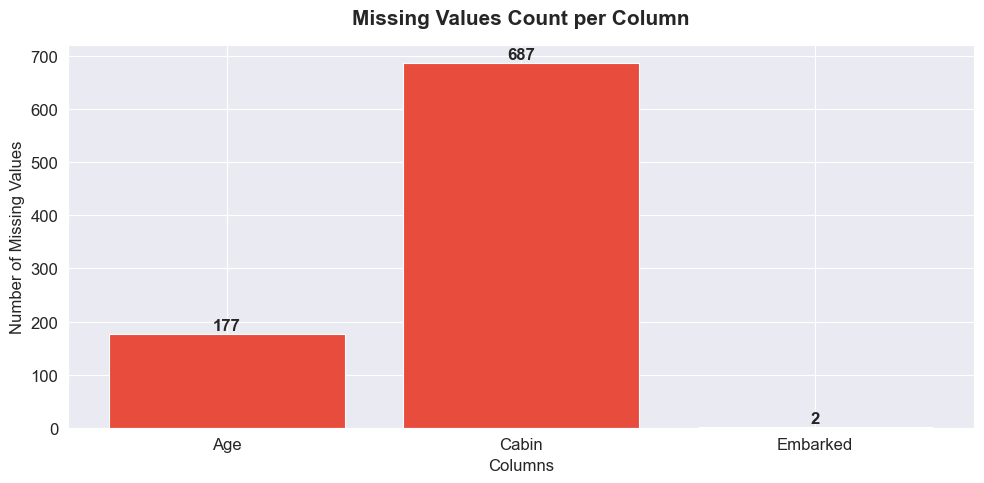

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0]
colors = ['#e74c3c' if v > 50 else '#e67e22' for v in missing_vals.values]
bars = ax.bar(missing_vals.index, missing_vals.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, missing_vals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Missing Values Count per Column', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Columns', fontsize=12)
ax.set_ylabel('Number of Missing Values', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)
print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


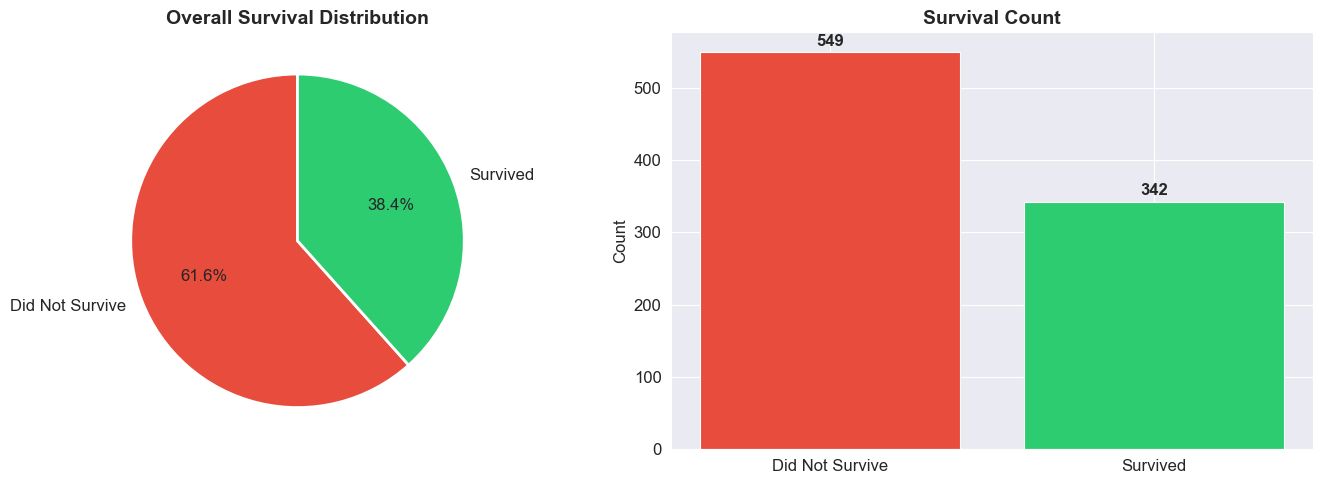

In [9]:
#Eda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

survived_counts = df['Survived'].value_counts()
colors_pie = ['#e74c3c', '#2ecc71']
axes[0].pie(survived_counts, labels=['Did Not Survive', 'Survived'],
            autopct='%1.1f%%', colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[0].set_title('Overall Survival Distribution', fontsize=14, fontweight='bold')

axes[1].bar(['Did Not Survive', 'Survived'], survived_counts, color=colors_pie, edgecolor='white', linewidth=0.8)
for i, v in enumerate(survived_counts):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Survival Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

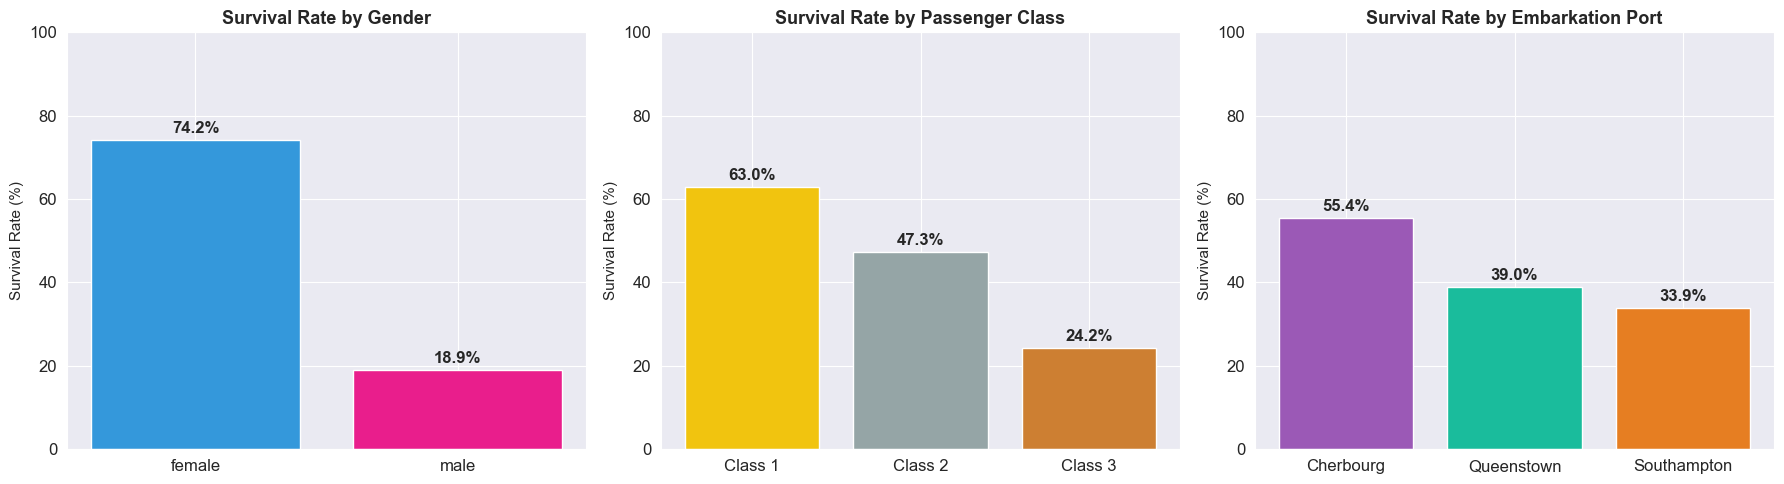

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sex_survival = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(sex_survival.index, sex_survival.values, color=['#3498db', '#e91e8c'], edgecolor='white')
for i, v in enumerate(sex_survival.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Survival Rate by Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0].set_ylim(0, 100)

pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
colors_class = ['#f1c40f', '#95a5a6', '#cd7f32']
axes[1].bar([f'Class {i}' for i in pclass_survival.index], pclass_survival.values, color=colors_class, edgecolor='white')
for i, v in enumerate(pclass_survival.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Survival Rate by Passenger Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)', fontsize=11)
axes[1].set_ylim(0, 100)

embarked_survival = df.groupby('Embarked')['Survived'].mean() * 100
port_labels = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
axes[2].bar([port_labels.get(e, e) for e in embarked_survival.index], embarked_survival.values,
            color=['#9b59b6', '#1abc9c', '#e67e22'], edgecolor='white')
for i, v in enumerate(embarked_survival.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[2].set_title('Survival Rate by Embarkation Port', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Survival Rate (%)', fontsize=11)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

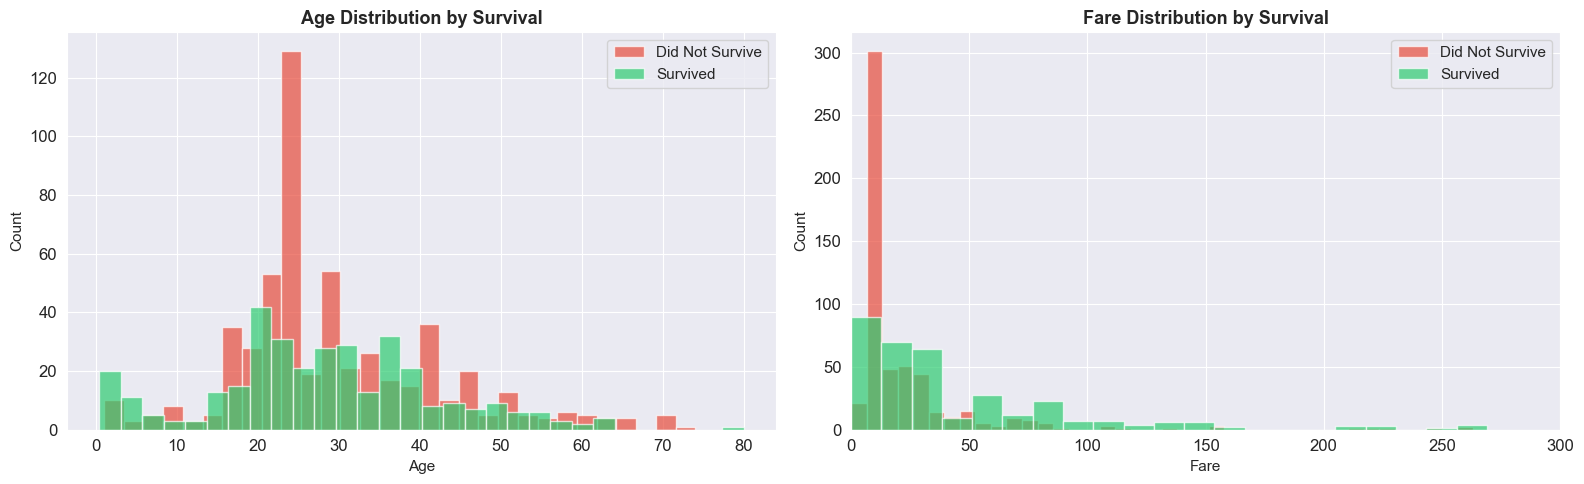

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for survived, color, label in zip([0, 1], ['#e74c3c', '#2ecc71'], ['Did Not Survive', 'Survived']):
    axes[0].hist(df[df['Survived'] == survived]['Age'], bins=30, alpha=0.7,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=11)

for survived, color, label in zip([0, 1], ['#e74c3c', '#2ecc71'], ['Did Not Survive', 'Survived']):
    axes[1].hist(df[df['Survived'] == survived]['Fare'], bins=40, alpha=0.7,
                 color=color, label=label, edgecolor='white')
axes[1].set_title('Fare Distribution by Survival', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fare', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_xlim(0, 300)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

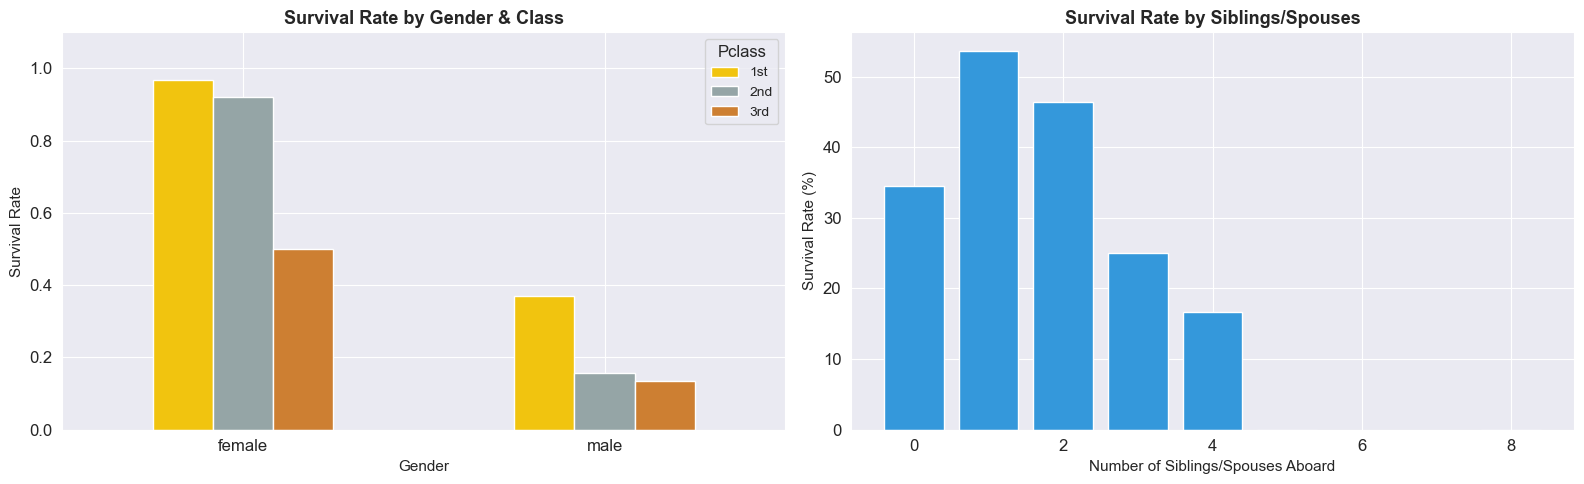

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct_sex_pclass = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
ct_sex_pclass.plot(kind='bar', ax=axes[0], color=['#f1c40f', '#95a5a6', '#cd7f32'],
                   edgecolor='white', rot=0)
axes[0].set_title('Survival Rate by Gender & Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Survival Rate', fontsize=11)
axes[0].legend(title='Pclass', labels=['1st', '2nd', '3rd'], fontsize=10)
axes[0].set_ylim(0, 1.1)

sibsp_survival = df.groupby('SibSp')['Survived'].mean() * 100
axes[1].bar(sibsp_survival.index, sibsp_survival.values, color='#3498db', edgecolor='white')
axes[1].set_title('Survival Rate by Siblings/Spouses', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Siblings/Spouses Aboard', fontsize=11)
axes[1].set_ylabel('Survival Rate (%)', fontsize=11)

plt.tight_layout()
plt.show()

In [13]:
#Feature engineering
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare'
)
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("Title Value Counts:")
print(df['Title'].value_counts())

Title Value Counts:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                       labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

df['FareBin'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

print("New Features Created: FamilySize, IsAlone, AgeBin, FareBin")
df[['Name', 'Title', 'FamilySize', 'IsAlone', 'AgeBin', 'FareBin']].head(10)

New Features Created: FamilySize, IsAlone, AgeBin, FareBin


,Name,Title,FamilySize,IsAlone,AgeBin,FareBin
0,"Braund, Mr. Owen Harris",Mr,2,0,Young Adult,Low
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,Adult,Very High
2,"Heikkinen, Miss. Laina",Miss,1,1,Young Adult,Medium
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,Young Adult,Very High
4,"Allen, Mr. William Henry",Mr,1,1,Young Adult,Medium
5,"Moran, Mr. James",Mr,1,1,Young Adult,Medium
6,"McCarthy, Mr. Timothy J",Mr,1,1,Adult,Very High
7,"Palsson, Master. Gosta Leonard",Master,5,0,Child,High
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,3,0,Young Adult,Medium
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,2,0,Teen,High


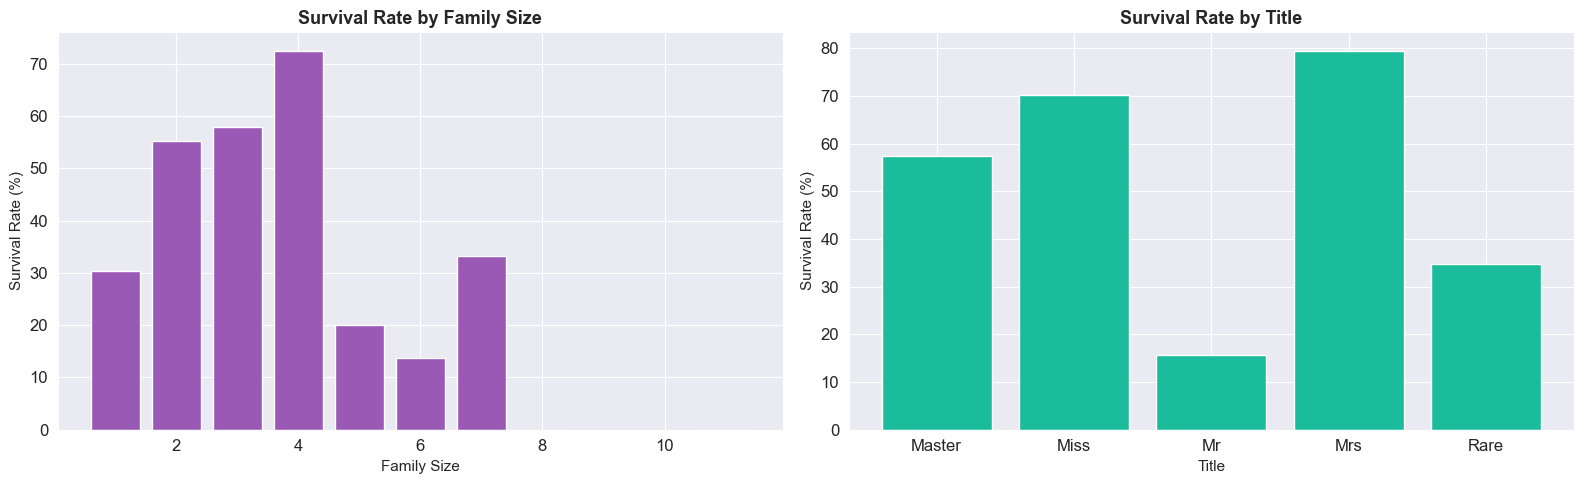

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

family_survival = df.groupby('FamilySize')['Survived'].mean() * 100
axes[0].bar(family_survival.index, family_survival.values, color='#9b59b6', edgecolor='white')
axes[0].set_title('Survival Rate by Family Size', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Family Size', fontsize=11)
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)

title_survival = df.groupby('Title')['Survived'].mean() * 100
axes[1].bar(title_survival.index, title_survival.values, color='#1abc9c', edgecolor='white')
axes[1].set_title('Survival Rate by Title', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Title', fontsize=11)
axes[1].set_ylabel('Survival Rate (%)', fontsize=11)

plt.tight_layout()
plt.show()

In [16]:
le = LabelEncoder()

df['Sex_encoded'] = le.fit_transform(df['Sex'])
df['Embarked_encoded'] = le.fit_transform(df['Embarked'])
df['Title_encoded'] = le.fit_transform(df['Title'])
df['AgeBin_encoded'] = le.fit_transform(df['AgeBin'])
df['FareBin_encoded'] = le.fit_transform(df['FareBin'])

features = [
    'Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare',
    'Embarked_encoded', 'Title_encoded', 'FamilySize', 'IsAlone',
    'AgeBin_encoded', 'FareBin_encoded'
]

X = df[features]
y = df['Survived']

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"\nFeatures Used: {features}")

Feature Matrix Shape: (891, 12)
Target Shape: (891,)

Features Used: ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_encoded', 'Title_encoded', 'FamilySize', 'IsAlone', 'AgeBin_encoded', 'FareBin_encoded']


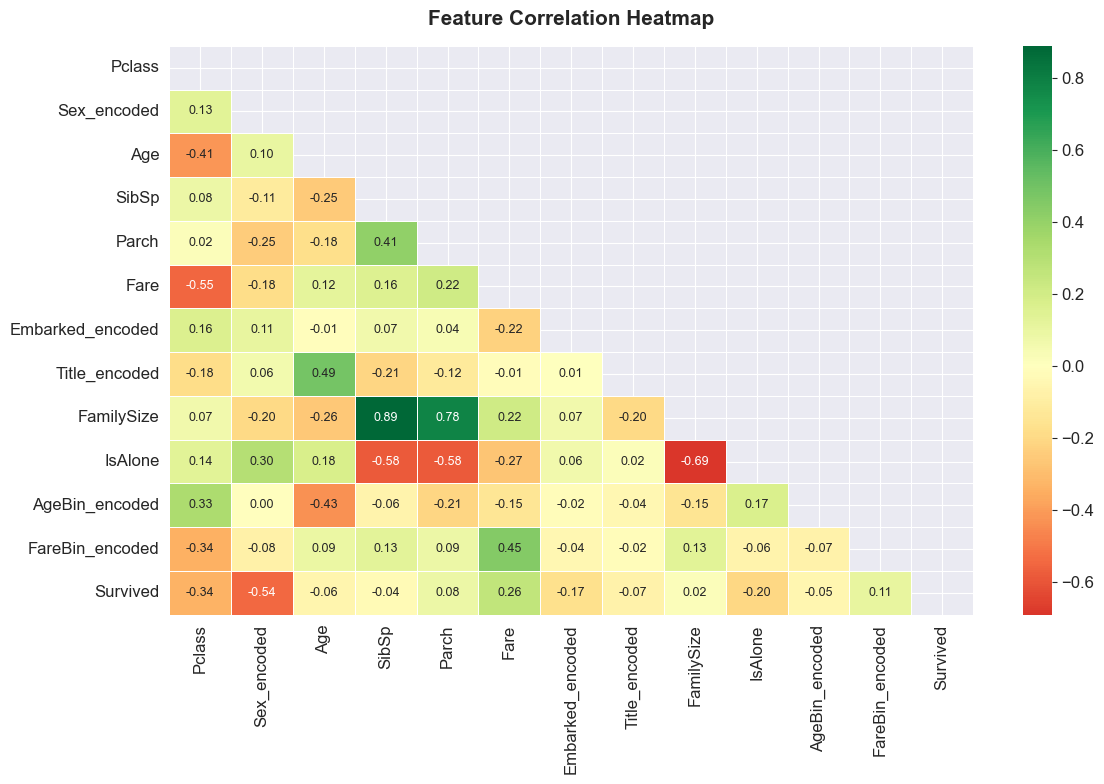

In [17]:
plt.figure(figsize=(12, 8))
corr_matrix = X.copy()
corr_matrix['Survived'] = y
mask = np.triu(np.ones_like(corr_matrix.corr(), dtype=bool))
sns.heatmap(corr_matrix.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, mask=mask,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [18]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set Size  : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing Set Size   : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining Survival Rate : {y_train.mean()*100:.1f}%")
print(f"Testing Survival Rate  : {y_test.mean()*100:.1f}%")

Training Set Size  : 712 samples (79.9%)
Testing Set Size   : 179 samples (20.1%)

Training Survival Rate : 38.3%
Testing Survival Rate  : 38.5%


In [19]:
#choose the model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

print("Models Selected:")
for name in models:
    print(f"  ✔ {name}")

Models Selected:
  ✔ Logistic Regression
  ✔ Random Forest
  ✔ XGBoost


In [20]:
#Train the model
trained_models = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} — Training Complete ✔")

Logistic Regression — Training Complete ✔
Random Forest — Training Complete ✔
XGBoost — Training Complete ✔


In [21]:
#Evaluate the model
results = {}

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

results_df = pd.DataFrame({
    name: {
        k: v for k, v in metrics.items() if k not in ['y_pred', 'y_prob']
    }
    for name, metrics in results.items()
}).T

results_df = results_df.round(4)
print("Model Evaluation Results:")
results_df

Model Evaluation Results:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8156,0.8103,0.6812,0.7402,0.8574
Random Forest,0.8045,0.7576,0.7246,0.7407,0.8179
XGBoost,0.8101,0.7536,0.7536,0.7536,0.8275


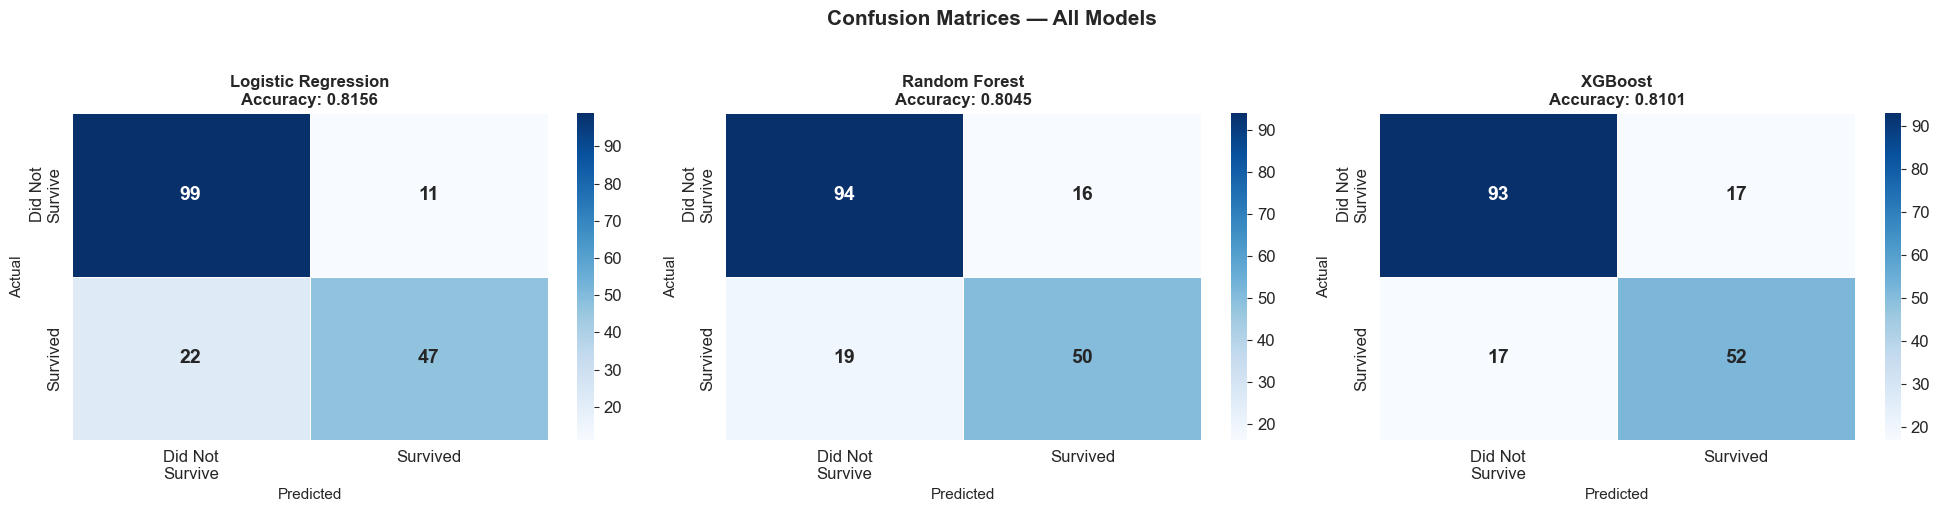

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

model_colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Did Not\nSurvive', 'Survived'],
                yticklabels=['Did Not\nSurvive', 'Survived'],
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

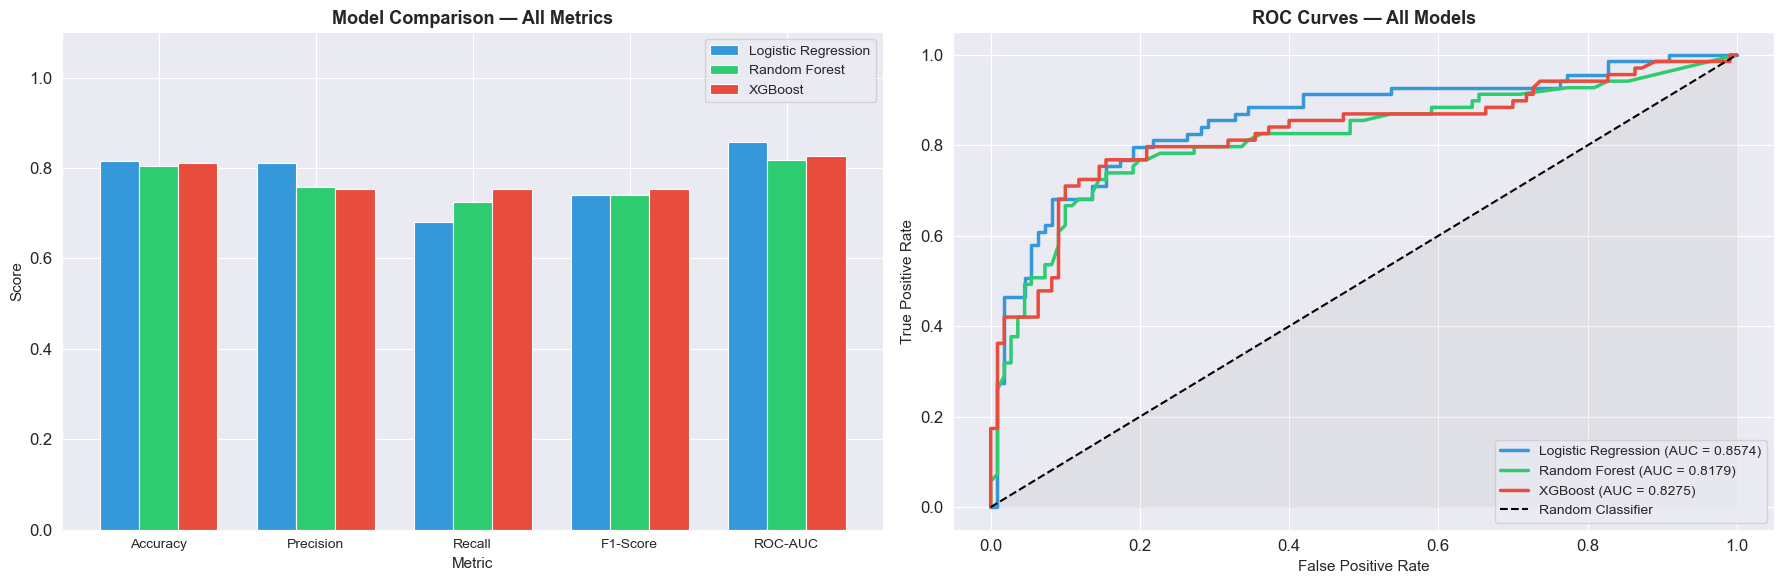

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

model_names = list(trained_models.keys())
for i, (name, color) in enumerate(zip(model_names, model_colors)):
    vals = [results[name][m] for m in metrics_to_plot]
    bars = axes[0].bar(x + i * width, vals, width, label=name, color=color,
                       edgecolor='white', linewidth=0.8)

axes[0].set_xlabel('Metric', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, fontsize=10)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1.1)

for name, color in zip(model_names, model_colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['ROC-AUC']
    axes[1].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC = {auc:.4f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='lower right')
axes[1].fill_between([0, 1], [0, 1], alpha=0.1, color='gray')

plt.tight_layout()
plt.show()

In [24]:
print("Cross-Validation Scores (5-Fold):")
print("-" * 55)

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:25s}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Validation Scores (5-Fold):
-------------------------------------------------------
Logistic Regression      : 0.7993 ± 0.0283
Random Forest            : 0.7964 ± 0.0325
XGBoost                  : 0.7838 ± 0.0324


In [25]:
for name in model_names:
    print(f"\n{'='*55}")
    print(f"Classification Report — {name}")
    print('='*55)
    print(classification_report(y_test, results[name]['y_pred'],
                                target_names=['Did Not Survive', 'Survived']))


Classification Report — Logistic Regression
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.90      0.86       110
       Survived       0.81      0.68      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      0.79      0.80       179
   weighted avg       0.82      0.82      0.81       179


Classification Report — Random Forest
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.85      0.84       110
       Survived       0.76      0.72      0.74        69

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179


Classification Report — XGBoost
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.85      0.85       110
       Survived       0.75      0.75      0.75        69

       accuracy     

In [ ]:
#Improve the model
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train, y_train)
print(f"Best Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best Cross-Validation Accuracy: {rf_grid.best_score_:.4f}")

In [29]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

xgb_grid.fit(X_train, y_train)
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Best Cross-Validation Accuracy: {xgb_grid.best_score_:.4f}")

Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.8273


In [30]:
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

tuned_models = {
    'Logistic Regression (Base)': trained_models['Logistic Regression'],
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb
}

tuned_results = {}

for name, model in tuned_models.items():
    if 'Logistic' in name:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

tuned_df = pd.DataFrame(tuned_results).T.round(4)
print("Tuned Model Performance:")
tuned_df

Tuned Model Performance:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression (Base),0.8156,0.8103,0.6812,0.7402,0.8574
Random Forest (Tuned),0.8101,0.7869,0.6957,0.7385,0.8431
XGBoost (Tuned),0.8212,0.8136,0.6957,0.7500,0.8516


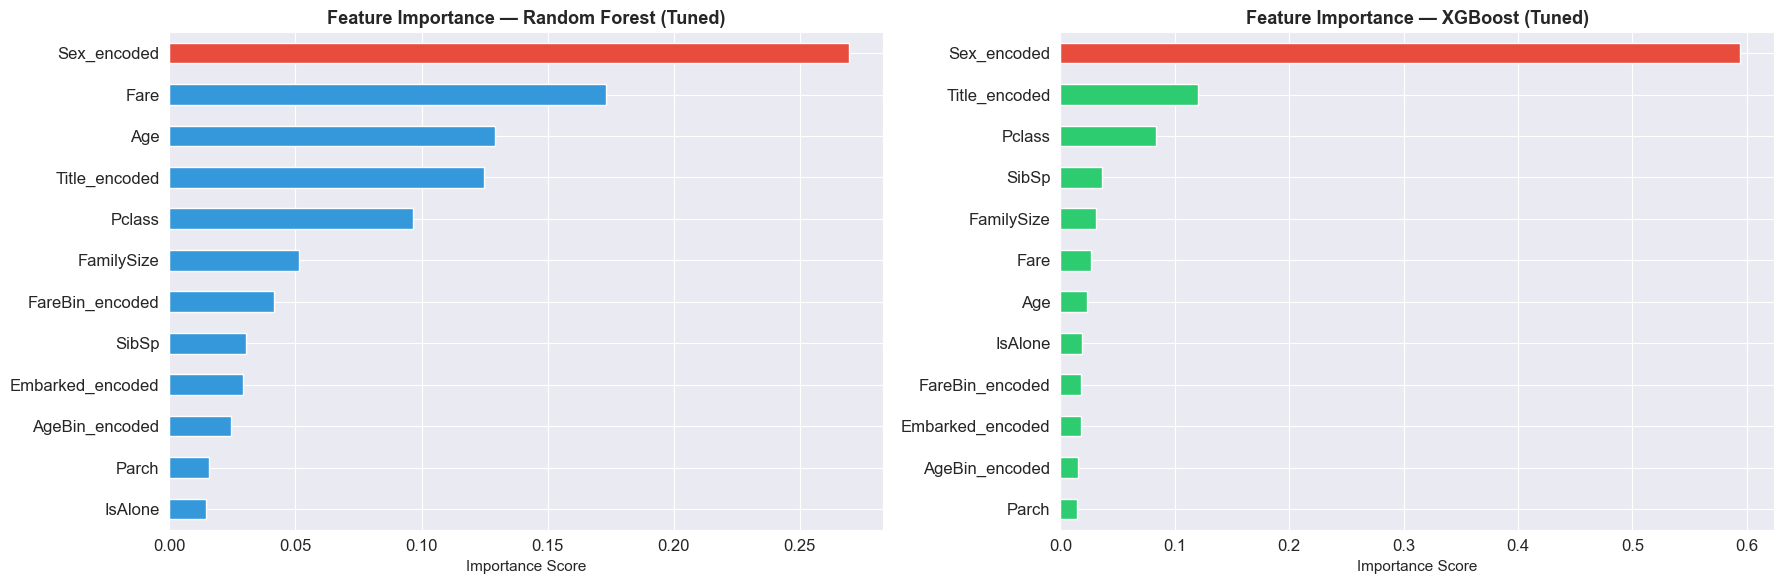

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rf_importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=True)
colors_imp = ['#e74c3c' if v == rf_importances.max() else '#3498db' for v in rf_importances.values]
rf_importances.plot(kind='barh', ax=axes[0], color=colors_imp, edgecolor='white')
axes[0].set_title('Feature Importance — Random Forest (Tuned)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score', fontsize=11)

xgb_importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values(ascending=True)
colors_xgb = ['#e74c3c' if v == xgb_importances.max() else '#2ecc71' for v in xgb_importances.values]
xgb_importances.plot(kind='barh', ax=axes[1], color=colors_xgb, edgecolor='white')
axes[1].set_title('Feature Importance — XGBoost (Tuned)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=11)

plt.tight_layout()
plt.show()

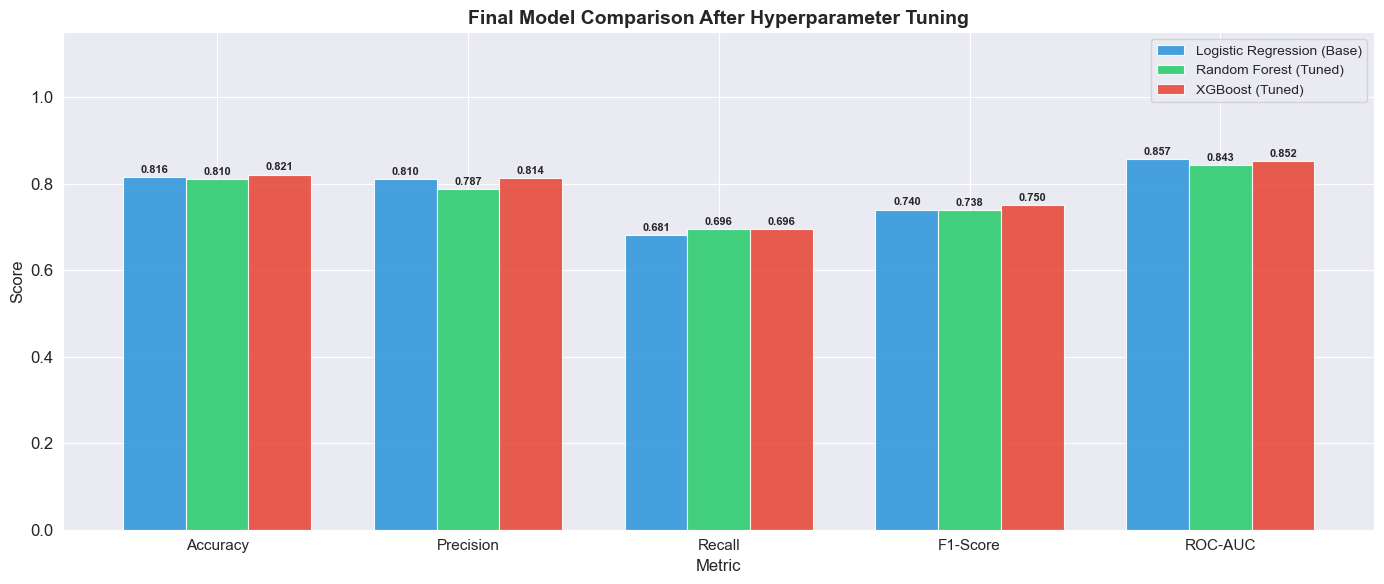

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

all_model_names = list(tuned_results.keys())
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_plot))
width = 0.25
bar_colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (name, color) in enumerate(zip(all_model_names, bar_colors)):
    vals = [tuned_results[name][m] for m in metrics_plot]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color,
                  edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model Comparison After Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

In [33]:
# Final Results & Key Insights
best_model_name = max(tuned_results, key=lambda x: tuned_results[x]['ROC-AUC'])
best_metrics = tuned_results[best_model_name]

print("="*60)
print(" TITANIC SURVIVAL PREDICTION — FINAL SUMMARY")
print("="*60)
print(f"\n  Best Model        : {best_model_name}")
print(f"  Accuracy          : {best_metrics['Accuracy']*100:.2f}%")
print(f"  Precision         : {best_metrics['Precision']:.4f}")
print(f"  Recall            : {best_metrics['Recall']:.4f}")
print(f"  F1-Score          : {best_metrics['F1-Score']:.4f}")
print(f"  ROC-AUC Score     : {best_metrics['ROC-AUC']:.4f}")
print("\n" + "="*60)
print("\n  KEY INSIGHTS:")
print("  → Gender is the strongest predictor of survival.")
print("  → Passenger Class (Pclass) strongly influences survival.")
print("  → Title (extracted from name) is a highly predictive feature.")
print("  → Passengers traveling alone had lower survival rates.")
print("  → Children had higher survival probability.")
print("\n" + "="*60)

 TITANIC SURVIVAL PREDICTION — FINAL SUMMARY

  Best Model        : Logistic Regression (Base)
  Accuracy          : 81.56%
  Precision         : 0.8103
  Recall            : 0.6812
  F1-Score          : 0.7402
  ROC-AUC Score     : 0.8574


  KEY INSIGHTS:
  → Gender is the strongest predictor of survival.
  → Passenger Class (Pclass) strongly influences survival.
  → Title (extracted from name) is a highly predictive feature.
  → Passengers traveling alone had lower survival rates.
  → Children had higher survival probability.



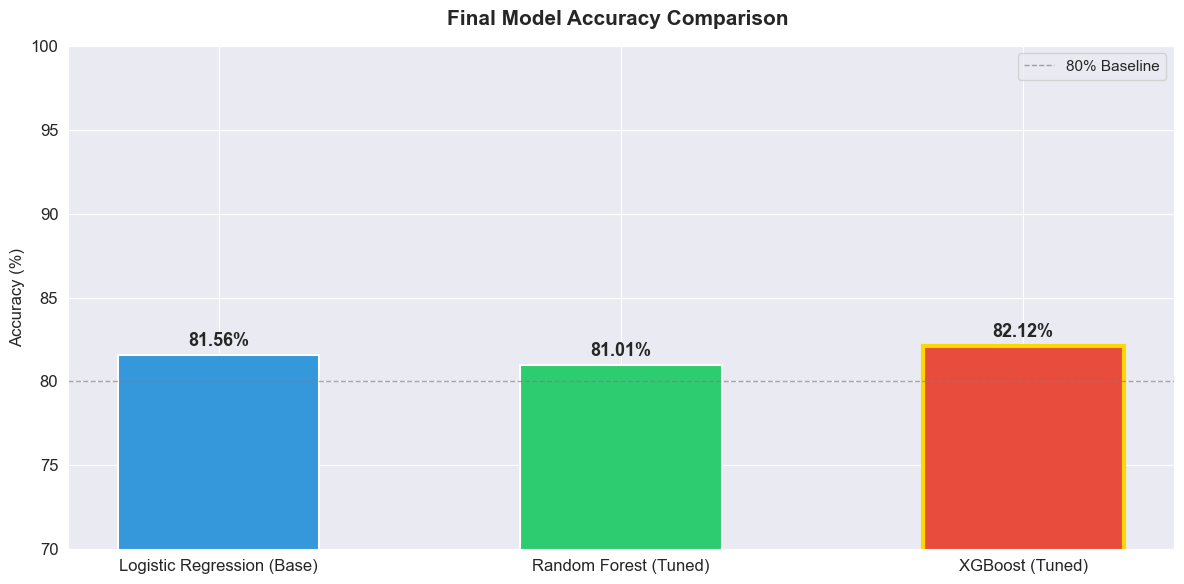


 Best Performing Model: XGBoost (Tuned) with 82.12% Accuracy


In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

comparison_data = pd.DataFrame(tuned_results).T['Accuracy'] * 100

bar_colors_final = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(comparison_data.index, comparison_data.values, color=bar_colors_final,
               edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, comparison_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

best_idx = comparison_data.values.argmax()
bars[best_idx].set_edgecolor('#ffd700')
bars[best_idx].set_linewidth(3)

ax.set_title('Final Model Accuracy Comparison ', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(70, 100)
ax.axhline(y=80, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='80% Baseline')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()
print(f"\n Best Performing Model: {comparison_data.idxmax()} with {comparison_data.max():.2f}% Accuracy")